# Correlations and Copulas in Gendantic

Real-world data has correlations:
- Older employees tend to have more experience
- Higher performers often get larger bonuses
- Risk and loss tend to spike together

Gendantic uses **copulas** to model these relationships while preserving each field's marginal distribution.

In [1]:
from typing import Annotated

import numpy as np
import matplotlib.pyplot as plt
from pydantic import BaseModel

from gendantic import (
    generate_synthetic_data,
    Correlations,
    CopulaType,
    Normal,
    Uniform,
    Beta,
    LogNormal,
)

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

## Basic Correlations

Define correlations using the `__correlations__` class attribute:

In [2]:
class Employee(BaseModel):
    """Employee with correlated fields."""
    name: str
    
    age: Annotated[int, Uniform(min=22, max=65)]
    years_experience: Annotated[int, Uniform(min=0, max=40)]
    salary: Annotated[float, Normal(mean=75000, std=20000)]
    
    # Define correlations between distribution fields
    __correlations__ = Correlations(
        ("age", "years_experience", 0.85),  # Strong: older = more experience
        ("years_experience", "salary", 0.6),  # Moderate: experience -> higher pay
        ("age", "salary", 0.4),  # Weaker direct correlation
    )

employees = await generate_synthetic_data(Employee, count=500, seed=42)

Correlation Matrix:
  Age-Experience: 0.86 (target: 0.85)
  Experience-Salary: 0.64 (target: 0.60)
  Age-Salary: 0.47 (target: 0.40)


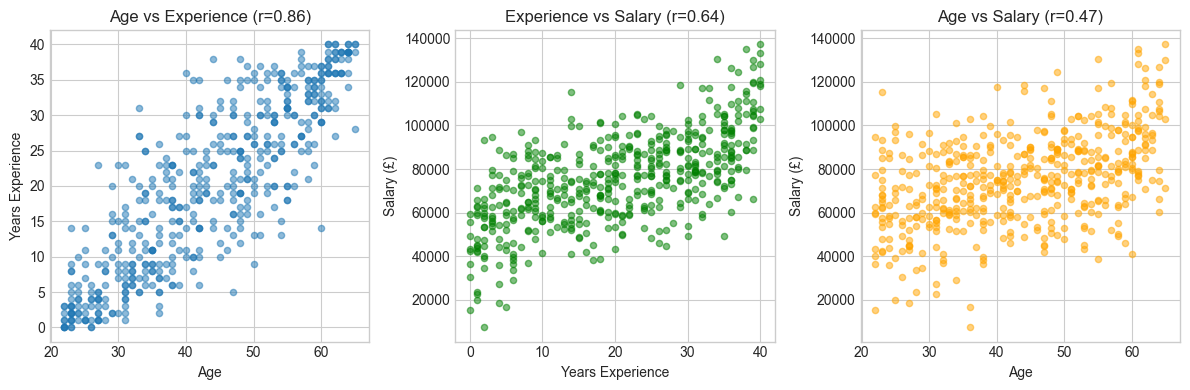

In [3]:
# Verify the correlations
ages = [e.age for e in employees]
experience = [e.years_experience for e in employees]
salaries = [e.salary for e in employees]

print("Correlation Matrix:")
print(f"  Age-Experience: {np.corrcoef(ages, experience)[0,1]:.2f} (target: 0.85)")
print(f"  Experience-Salary: {np.corrcoef(experience, salaries)[0,1]:.2f} (target: 0.60)")
print(f"  Age-Salary: {np.corrcoef(ages, salaries)[0,1]:.2f} (target: 0.40)")

# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].scatter(ages, experience, alpha=0.5, s=20)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Years Experience')
axes[0].set_title(f'Age vs Experience (r={np.corrcoef(ages, experience)[0,1]:.2f})')

axes[1].scatter(experience, salaries, alpha=0.5, s=20, color='green')
axes[1].set_xlabel('Years Experience')
axes[1].set_ylabel('Salary (£)')
axes[1].set_title(f'Experience vs Salary (r={np.corrcoef(experience, salaries)[0,1]:.2f})')

axes[2].scatter(ages, salaries, alpha=0.5, s=20, color='orange')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Salary (£)')
axes[2].set_title(f'Age vs Salary (r={np.corrcoef(ages, salaries)[0,1]:.2f})')

plt.tight_layout()
plt.show()

In [4]:
# Show some examples - notice how values make sense together
print("\nSample employees (notice realistic age-experience-salary relationships):")
for emp in employees[:5]:
    print(f"  {emp.name}: Age {emp.age}, {emp.years_experience} yrs exp, £{emp.salary:,.0f}")


Sample employees (notice realistic age-experience-salary relationships):
  Ethan Johnson: Age 35, 11 yrs exp, £85,512
  Mia Parker: Age 23, 8 yrs exp, £84,992
  Alexander Clark: Age 39, 17 yrs exp, £77,290
  Olivia Hall: Age 61, 31 yrs exp, £77,162
  Isabella Taylor: Age 52, 20 yrs exp, £59,738


## Negative Correlations

Use negative values for inverse relationships:

Price-Demand correlation: -0.70 (target: -0.70)


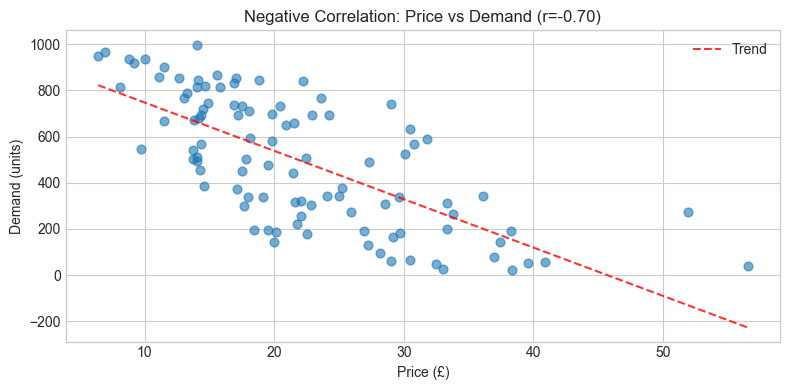

In [5]:
class Product(BaseModel):
    """Product with price-demand relationship."""
    name: str
    
    price: Annotated[float, LogNormal(mean=3, sigma=0.5)]
    demand: Annotated[int, Uniform(min=10, max=1000)]
    
    # Negative correlation: higher price = lower demand
    __correlations__ = Correlations(
        ("price", "demand", -0.7),
    )

products = await generate_synthetic_data(Product, count=100, seed=42)

prices = [p.price for p in products]
demands = [p.demand for p in products]

print(f"Price-Demand correlation: {np.corrcoef(prices, demands)[0,1]:.2f} (target: -0.70)")

# Scatter plot showing negative correlation
plt.figure(figsize=(8, 4))
plt.scatter(prices, demands, alpha=0.6, s=40)
plt.xlabel('Price (£)')
plt.ylabel('Demand (units)')
plt.title(f'Negative Correlation: Price vs Demand (r={np.corrcoef(prices, demands)[0,1]:.2f})')

# Add trend line
z = np.polyfit(prices, demands, 1)
p = np.poly1d(z)
x_line = np.linspace(min(prices), max(prices), 100)
plt.plot(x_line, p(x_line), "r--", alpha=0.8, label='Trend')
plt.legend()
plt.tight_layout()
plt.show()

## Copula Types

Different copulas model different dependency structures:

| Copula | Tail Dependence | Use Case |
|--------|-----------------|----------|
| `gaussian` | None | Standard correlations, most business data |
| `student_t` | Both tails | Financial data, extreme events together |
| `clayton` | Lower tail | Risk modelling, crashes happen together |
| `gumbel` | Upper tail | Success metrics, booms happen together |
| `frank` | None | Weak to moderate symmetric correlations |

In [6]:
class FinancialData(BaseModel):
    """Financial data with different copula types."""
    ticker: str
    
    stock_return: Annotated[float, Normal(mean=0.07, std=0.15)]
    bond_return: Annotated[float, Normal(mean=0.03, std=0.05)]
    
    performance_score: Annotated[float, Beta(alpha=5, beta=2)]
    bonus_pct: Annotated[float, Normal(mean=10, std=5)]
    
    risk_score: Annotated[float, Beta(alpha=2, beta=5)]
    loss_severity: Annotated[float, LogNormal(mean=8, sigma=1)]
    
    __correlations__ = Correlations(
        # Student's t: extreme values (crashes/booms) happen together
        ("stock_return", "bond_return", 0.5, "student_t"),
        
        # Gumbel: upper tail dependence - high performers get big bonuses
        ("performance_score", "bonus_pct", 0.7, "gumbel"),
        
        # Clayton: lower tail dependence - high risk = high loss
        ("risk_score", "loss_severity", 0.6, "clayton"),
    )

financial = await generate_synthetic_data(FinancialData, count=500, seed=42)

Correlations by copula type:
  Stock-Bond (student_t): 0.51
  Performance-Bonus (gumbel): 0.70
  Risk-Loss (clayton): 0.54


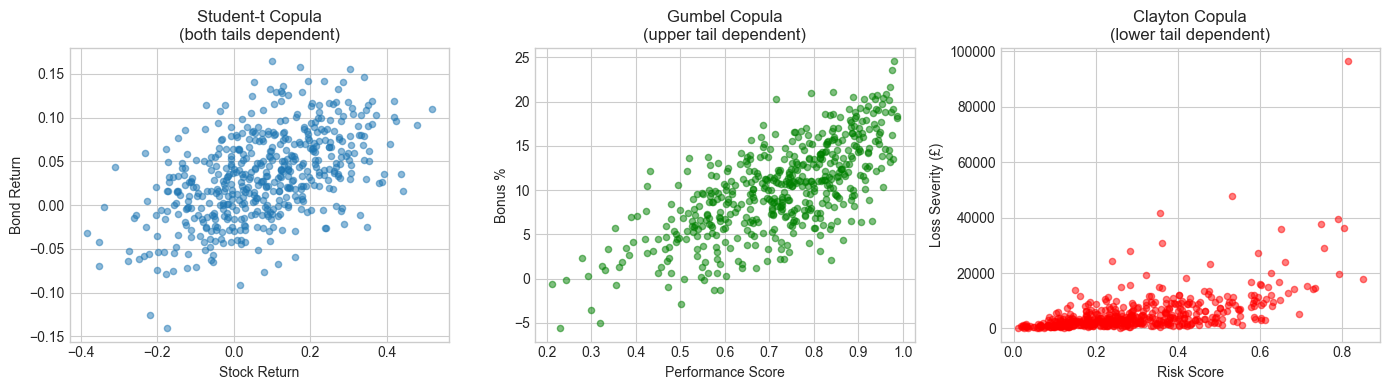

In [7]:
# Verify correlations
stock = [f.stock_return for f in financial]
bond = [f.bond_return for f in financial]
perf = [f.performance_score for f in financial]
bonus = [f.bonus_pct for f in financial]
risk = [f.risk_score for f in financial]
loss = [f.loss_severity for f in financial]

print("Correlations by copula type:")
print(f"  Stock-Bond (student_t): {np.corrcoef(stock, bond)[0,1]:.2f}")
print(f"  Performance-Bonus (gumbel): {np.corrcoef(perf, bonus)[0,1]:.2f}")
print(f"  Risk-Loss (clayton): {np.corrcoef(risk, loss)[0,1]:.2f}")

# Scatter plots comparing copula types
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(stock, bond, alpha=0.5, s=20)
axes[0].set_xlabel('Stock Return')
axes[0].set_ylabel('Bond Return')
axes[0].set_title('Student-t Copula\n(both tails dependent)')

axes[1].scatter(perf, bonus, alpha=0.5, s=20, color='green')
axes[1].set_xlabel('Performance Score')
axes[1].set_ylabel('Bonus %')
axes[1].set_title('Gumbel Copula\n(upper tail dependent)')

axes[2].scatter(risk, loss, alpha=0.5, s=20, color='red')
axes[2].set_xlabel('Risk Score')
axes[2].set_ylabel('Loss Severity (£)')
axes[2].set_title('Clayton Copula\n(lower tail dependent)')

plt.tight_layout()
plt.show()

## Tail Dependence Visualization

The key difference between copulas is how they behave in the tails:

In [8]:
# Compare tail behavior
print("Gumbel (upper tail) - Top performers get top bonuses:")
top_performers = [f for f in financial if f.performance_score > 0.9]
avg_bonus_top = np.mean([f.bonus_pct for f in top_performers])
avg_bonus_all = np.mean([f.bonus_pct for f in financial])
print(f"  Top 10% performers avg bonus: {avg_bonus_top:.1f}%")
print(f"  Overall avg bonus: {avg_bonus_all:.1f}%")

print("\nClayton (lower tail) - High risk leads to severe losses:")
high_risk = [f for f in financial if f.risk_score > 0.5]
avg_loss_high = np.mean([f.loss_severity for f in high_risk])
avg_loss_all = np.mean([f.loss_severity for f in financial])
print(f"  High risk avg loss: £{avg_loss_high:,.0f}")
print(f"  Overall avg loss: £{avg_loss_all:,.0f}")

Gumbel (upper tail) - Top performers get top bonuses:
  Top 10% performers avg bonus: 16.2%
  Overall avg bonus: 10.1%

Clayton (lower tail) - High risk leads to severe losses:
  High risk avg loss: £14,083
  Overall avg loss: £5,229


## Three+ Field Correlations

Model complex relationships between multiple fields:

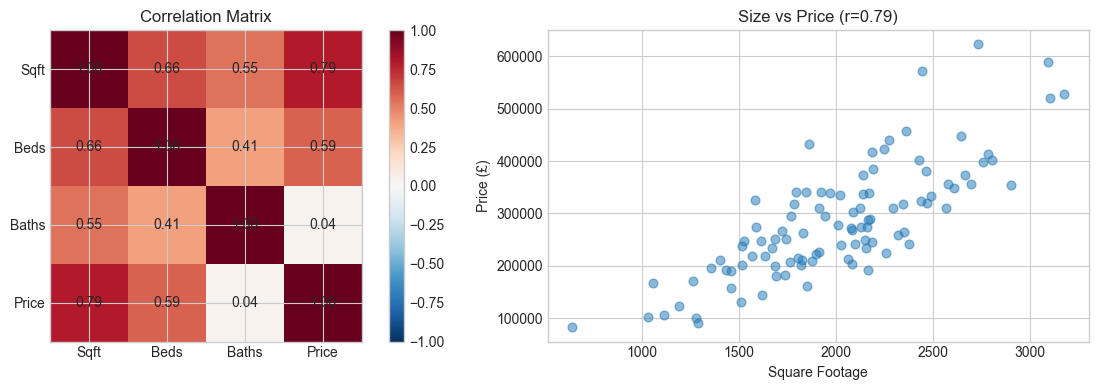


Sample properties (notice correlated features):
  Small: 639 sqft, 1br/2ba, £82,750
  Small: 1029 sqft, 2br/3ba, £103,175
  Large: 3176 sqft, 6br/4ba, £526,802
  Large: 3101 sqft, 6br/4ba, £520,540


In [9]:
class RealEstateProperty(BaseModel):
    """Property with multiple correlated features."""
    address: str
    
    sqft: Annotated[int, Normal(mean=2000, std=500)]
    bedrooms: Annotated[int, Uniform(min=1, max=6)]
    bathrooms: Annotated[int, Uniform(min=1, max=4)]
    price: Annotated[float, LogNormal(mean=12.5, sigma=0.4)]
    
    __correlations__ = Correlations(
        ("sqft", "bedrooms", 0.7),      # Bigger homes have more bedrooms
        ("sqft", "bathrooms", 0.6),     # Bigger homes have more bathrooms
        ("bedrooms", "bathrooms", 0.5), # More bedrooms = more bathrooms
        ("sqft", "price", 0.8),         # Size drives price
        ("bedrooms", "price", 0.6),     # Bedrooms affect price
    )

properties = await generate_synthetic_data(RealEstateProperty, count=100, seed=42)

# Extract data for correlation matrix
sqft = [p.sqft for p in properties]
beds = [p.bedrooms for p in properties]
baths = [p.bathrooms for p in properties]
prices = [p.price for p in properties]

# Build correlation matrix
data = np.array([sqft, beds, baths, prices])
corr_matrix = np.corrcoef(data)

# Plot correlation heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Heatmap
labels = ['Sqft', 'Beds', 'Baths', 'Price']
im = ax1.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax1.set_xticks(range(len(labels)))
ax1.set_yticks(range(len(labels)))
ax1.set_xticklabels(labels)
ax1.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax1.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', fontsize=10)
ax1.set_title('Correlation Matrix')
plt.colorbar(im, ax=ax1)

# Scatter plot: sqft vs price
ax2.scatter(sqft, prices, alpha=0.5, s=40)
ax2.set_xlabel('Square Footage')
ax2.set_ylabel('Price (£)')
ax2.set_title(f'Size vs Price (r={np.corrcoef(sqft, prices)[0,1]:.2f})')

plt.tight_layout()
plt.show()

print("\nSample properties (notice correlated features):")
for p in sorted(properties, key=lambda x: x.sqft)[:2]:
    print(f"  Small: {p.sqft} sqft, {p.bedrooms}br/{p.bathrooms}ba, £{p.price:,.0f}")
for p in sorted(properties, key=lambda x: -x.sqft)[:2]:
    print(f"  Large: {p.sqft} sqft, {p.bedrooms}br/{p.bathrooms}ba, £{p.price:,.0f}")

## Default Copula

Set a default copula for all correlations:

In [10]:
class PortfolioData(BaseModel):
    fund_name: str
    
    equity_return: Annotated[float, Normal(mean=0.08, std=0.18)]
    bond_return: Annotated[float, Normal(mean=0.04, std=0.06)]
    commodity_return: Annotated[float, Normal(mean=0.05, std=0.20)]
    
    # All correlations use student_t (fat tails) by default
    __correlations__ = Correlations(
        ("equity_return", "bond_return", 0.3),
        ("equity_return", "commodity_return", 0.4),
        ("bond_return", "commodity_return", 0.2),
        default_copula="student_t",  # All use student_t
    )

portfolio = await generate_synthetic_data(PortfolioData, count=100, seed=42)
print(f"Generated {len(portfolio)} portfolio records with student_t copula")

Generated 100 portfolio records with student_t copula


## Copula Selection Guide

**Gaussian (default)**:
- Standard correlations
- Most business data
- No tail dependence

**Student's t**:
- Financial returns
- Extreme events happen together
- Heavy tails on both sides

**Gumbel**:
- Success metrics
- High performers cluster together
- Upper tail dependence

**Clayton**:
- Risk modelling
- Failures/crashes happen together
- Lower tail dependence

**Frank**:
- Symmetric, no tail dependence
- Weak to moderate correlations
- Similar to Gaussian but different structure